In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque
from tqdm import trange

In [2]:
class MaskedLinear(nn.Linear):
    def __init__(self, in_features, out_features):
        super().__init__(in_features, out_features)
        self.register_buffer("weight_mask", torch.ones_like(self.weight))

    def forward(self, input):
        return F.linear(input, self.weight * self.weight_mask, self.bias)

class SquashedNormal:
    def __init__(self, mu, std):
        self.base_dist = torch.distributions.Normal(mu, std)

    def rsample(self):
        sample = self.base_dist.rsample()
        return torch.tanh(sample)

    def log_prob(self, value):
        raw_action = torch.atanh(value.clamp(-0.999, 0.999))
        log_prob = self.base_dist.log_prob(raw_action)
        log_prob -= torch.log(1 - value.pow(2) + 1e-6)
        return log_prob.sum(dim=-1)

class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.fc1 = MaskedLinear(state_dim, hidden_dim)
        self.fc2 = MaskedLinear(hidden_dim, hidden_dim)
        self.mu = MaskedLinear(hidden_dim, action_dim)
        self.log_std = MaskedLinear(hidden_dim, action_dim)

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        mu = self.mu(x)
        log_std = self.log_std(x).clamp(-20, 2)
        std = torch.exp(log_std)
        dist = SquashedNormal(mu, std)
        action = dist.rsample()
        log_prob = dist.log_prob(action)
        return action, log_prob

class DoubleCritic(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.q1_fc1 = MaskedLinear(state_dim + action_dim, hidden_dim)
        self.q1_fc2 = MaskedLinear(hidden_dim, hidden_dim)
        self.q1_out = MaskedLinear(hidden_dim, 1)

        self.q2_fc1 = MaskedLinear(state_dim + action_dim, hidden_dim)
        self.q2_fc2 = MaskedLinear(hidden_dim, hidden_dim)
        self.q2_out = MaskedLinear(hidden_dim, 1)

    def forward(self, state, action):
        x = torch.cat([state, action], dim=-1)

        q1 = F.relu(self.q1_fc1(x))
        q1 = F.relu(self.q1_fc2(q1))
        q1 = self.q1_out(q1)

        q2 = F.relu(self.q2_fc1(x))
        q2 = F.relu(self.q2_fc2(q2))
        q2 = self.q2_out(q2)

        return q1.squeeze(-1), q2.squeeze(-1)

class ReplayBuffer:
    def __init__(self, max_size=10000):
        self.buffer = deque(maxlen=max_size)

    def add(self, transition):
        self.buffer.append(transition)

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        batch = list(zip(*batch))
        return tuple(torch.tensor(np.array(x), dtype=torch.float32) for x in batch)

    def __len__(self):
        return len(self.buffer)

class DAPDController:
    def __init__(self, model, sparsity=0.95):
        self.model = model
        self.sparsity = sparsity

    def compute_saliency(self, loss_fn, data_batch):
        self.model.zero_grad()
        loss = loss_fn(self.model, data_batch)
        loss = torch.tensor(loss, requires_grad=True)
        loss.backward()
        grads_abs = []
        for module in self.model.modules():
            if isinstance(module, MaskedLinear):
                grads_abs.append(torch.abs(module.weight * module.weight.grad))
        return grads_abs

    def update(self, data_batch, loss_fn):
        saliencies = self.compute_saliency(loss_fn, data_batch)
        all_scores = torch.cat([x.view(-1) for x in saliencies])
        num_params_to_keep = int((1 - self.sparsity) * all_scores.numel())
        if num_params_to_keep == 0:
            return
        threshold, _ = torch.kthvalue(all_scores, num_params_to_keep)
        keep_masks = [(x >= threshold).float() for x in saliencies]

        idx = 0
        for module in self.model.modules():
            if isinstance(module, MaskedLinear):
                module.weight_mask.data = keep_masks[idx].to(module.weight.device)
                idx += 1

class SACAgent:
    def __init__(self, state_dim, action_dim, hidden_dim=128, gamma=0.99, alpha=0.2):
        self.actor = Actor(state_dim, action_dim, hidden_dim)
        self.critic = DoubleCritic(state_dim, action_dim, hidden_dim)
        self.target_critic = DoubleCritic(state_dim, action_dim, hidden_dim)
        self.target_critic.load_state_dict(self.critic.state_dict())

        self.actor_opt = torch.optim.Adam(self.actor.parameters(), lr=3e-4)
        self.critic_opt = torch.optim.Adam(self.critic.parameters(), lr=3e-4)

        self.gamma = gamma
        self.alpha = alpha

    def update(self, batch):
        states, actions, rewards, next_states, dones = batch

        with torch.no_grad():
            next_actions, next_log_probs = self.actor(next_states)
            q1_target, q2_target = self.target_critic(next_states, next_actions)
            min_target = torch.min(q1_target, q2_target)
            target = rewards + self.gamma * (1 - dones) * (min_target - self.alpha * next_log_probs)

        q1, q2 = self.critic(states, actions)
        critic_loss = F.mse_loss(q1, target) + F.mse_loss(q2, target)
        self.critic_opt.zero_grad(); critic_loss.backward(); self.critic_opt.step()

        new_actions, log_probs = self.actor(states)
        q1_pi, q2_pi = self.critic(states, new_actions)
        actor_loss = (self.alpha * log_probs - torch.min(q1_pi, q2_pi)).mean()
        self.actor_opt.zero_grad(); actor_loss.backward(); self.actor_opt.step()

        with torch.no_grad():
            for param, target_param in zip(self.critic.parameters(), self.target_critic.parameters()):
                target_param.data.mul_(0.995)
                target_param.data.add_(0.005 * param.data)

        return actor_loss.item(), critic_loss.item()


In [ ]:
def train_dapd(env_name, num_episodes=200, batch_size=128, sparsity=0.95):
    env = gym.make(env_name)
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]

    agent = SACAgent(state_dim, action_dim)
    dapd_actor = DAPDController(agent.actor, sparsity=sparsity)
    dapd_critic = DAPDController(agent.critic, sparsity=sparsity)

    buffer = ReplayBuffer()
    warmup = True
    warmup_threshold = 8000

    actor_loss_log, critic_loss_log, return_log = [], [], []

    for ep in trange(num_episodes, desc="Training episodes"):
        state, _ = env.reset()
        done = False
        ep_return = 0

        while not done:
            with torch.no_grad():
                action, _ = agent.actor(torch.tensor(state, dtype=torch.float32).unsqueeze(0))
                action = action.numpy()[0]
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            buffer.add((state, action, reward, next_state, float(done)))
            state = next_state
            ep_return += reward

            if len(buffer) >= batch_size:
                batch = buffer.sample(batch_size)
                a_loss, c_loss = agent.update(batch)
                actor_loss_log.append(a_loss)
                critic_loss_log.append(c_loss)

        return_log.append(ep_return)

        if warmup and len(buffer) >= batch_size:
            batch = buffer.sample(batch_size)
            dapd_actor.update(batch, lambda m, b: agent.update(b)[0])
            dapd_critic.update(batch, lambda m, b: agent.update(b)[1])
            if ep_return >= warmup_threshold:
                warmup = False
                print(f"Warm-up ended at episode {ep}, return: {ep_return:.2f}")

        if ep % 10 == 0:
            print(f"Episode {ep}, Return: {ep_return:.2f}")

    env.close()
    return return_log, actor_loss_log, critic_loss_log

def plot_loss(actor_loss_log, critic_loss_log):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(actor_loss_log)
    plt.title("Actor Loss")
    plt.subplot(1, 2, 2)
    plt.plot(critic_loss_log)
    plt.title("Critic Loss")
    plt.tight_layout()
    plt.show()


def plot_returns(return_log):
    plt.figure(figsize=(6, 4))
    plt.plot(return_log)
    plt.title("Episode Returns")
    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

c:\Users\Proprio\AppData\Local\Programs\Python\Python311\Lib\site-packages\gymnasium\envs\registration.py:517: DeprecationWarning: WARN: The environment HalfCheetah-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


Training with sparsity 0.9


Training episodes:   0%|          | 1/200 [00:10<33:40, 10.15s/it]

Episode 0, Return: -147.48


Training episodes:   6%|▌         | 11/200 [02:01<35:53, 11.40s/it]

...

Training episodes:  90%|█████████ | 181/200 [29:04<03:10, 10.02s/it]

Episode 180, Return: -603.70


Training episodes:  96%|█████████▌| 191/200 [30:44<01:28,  9.84s/it]

Episode 190, Return: -602.22


Training episodes: 100%|██████████| 200/200 [32:13<00:00,  9.67s/it]


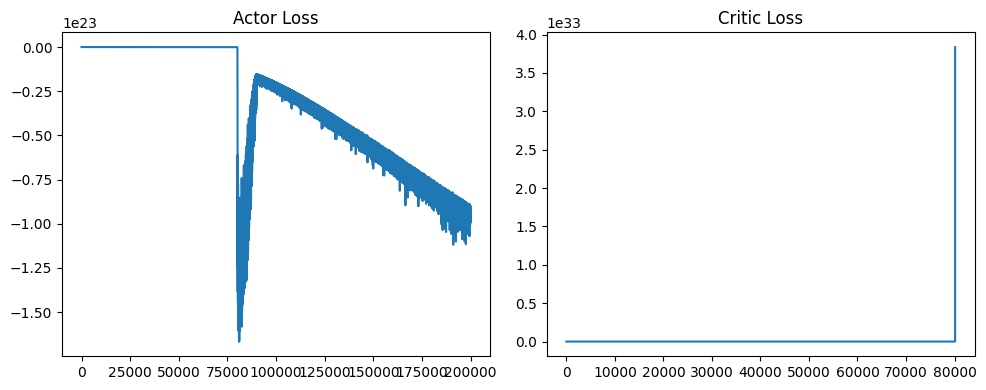

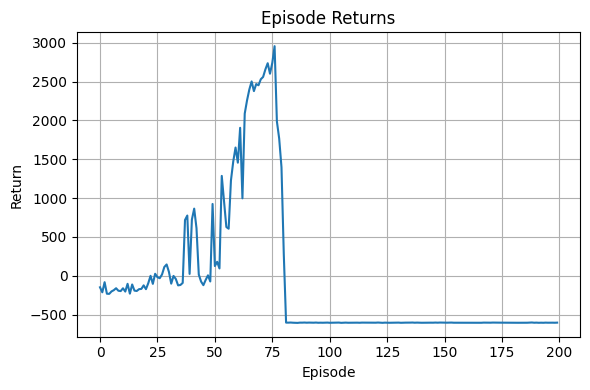

Training with sparsity 0.95


Training episodes:   0%|          | 1/200 [00:08<29:11,  8.80s/it]

Episode 0, Return: -188.16


Training episodes:   6%|▌         | 11/200 [01:44<28:36,  9.08s/it]

Episode 10, Return: -212.94


...

Training episodes:  90%|█████████ | 181/200 [27:15<02:45,  8.69s/it]

Episode 180, Return: 1100.67


Training episodes:  96%|█████████▌| 191/200 [28:42<01:17,  8.59s/it]

Episode 190, Return: 1183.40


Training episodes: 100%|██████████| 200/200 [30:00<00:00,  9.00s/it]


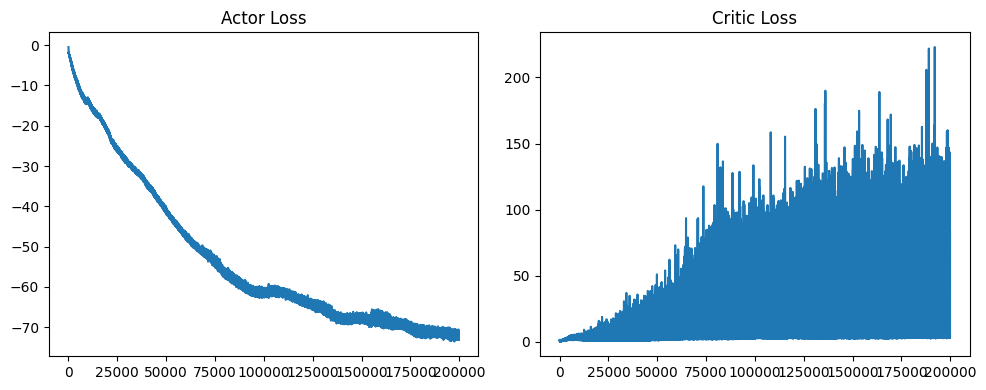

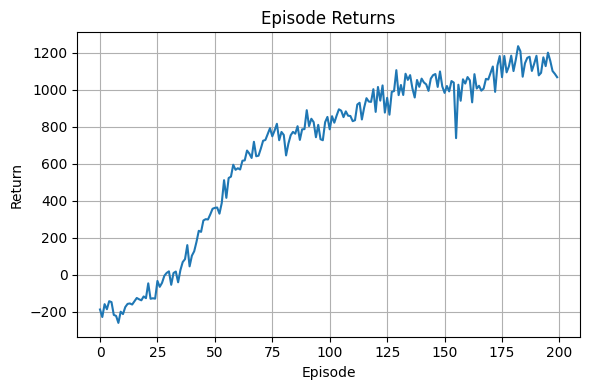

Training with sparsity 0.98


Training episodes:   0%|          | 1/200 [00:07<25:40,  7.74s/it]

Episode 0, Return: -358.30


Training episodes:   6%|▌         | 11/200 [01:35<27:54,  8.86s/it]

Episode 10, Return: -247.79


...

Training episodes:  90%|█████████ | 181/200 [25:28<02:40,  8.45s/it]

Episode 180, Return: 897.62


Training episodes:  96%|█████████▌| 191/200 [26:53<01:15,  8.43s/it]

Episode 190, Return: 1071.71


Training episodes: 100%|██████████| 200/200 [28:10<00:00,  8.45s/it]


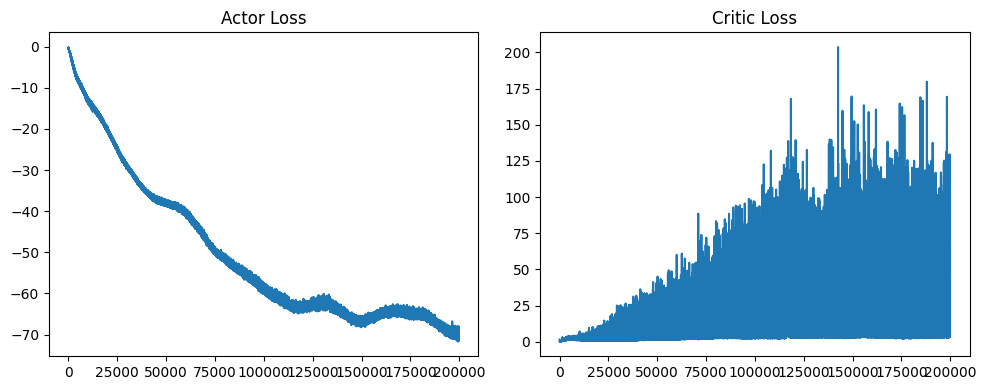

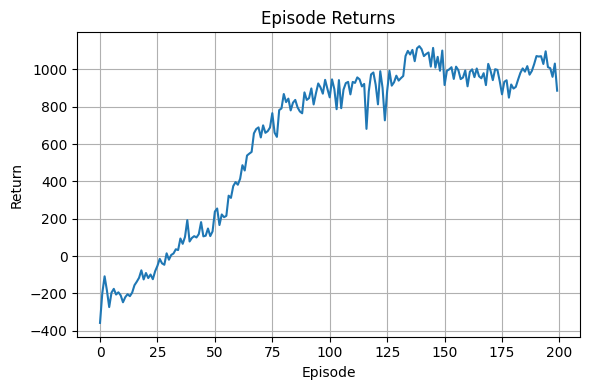

In [ ]:
for sparsity in [0.90, 0.95, 0.98]:
    print(f"Training with sparsity {sparsity}")
    returns, actor_loss, critic_loss = train_dapd("HalfCheetah-v4", num_episodes=200, sparsity=sparsity)
    plot_loss(actor_loss, critic_loss)
    plot_returns(returns)

c:\Users\Proprio\AppData\Local\Programs\Python\Python311\Lib\site-packages\gymnasium\envs\registration.py:517: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


Training with sparsity 0.9


Training episodes:   0%|          | 0/200 [00:00<?, ?it/s]

Episode 0, Return: 7.01


Training episodes:   6%|▌         | 11/200 [00:01<00:31,  6.04it/s]

...

Training episodes:  90%|█████████ | 181/200 [02:22<00:19,  1.02s/it]

Episode 180, Return: 236.98


Training episodes:  96%|█████████▌| 191/200 [02:33<00:10,  1.19s/it]

Episode 190, Return: 259.41


Training episodes: 100%|██████████| 200/200 [02:44<00:00,  1.22it/s]


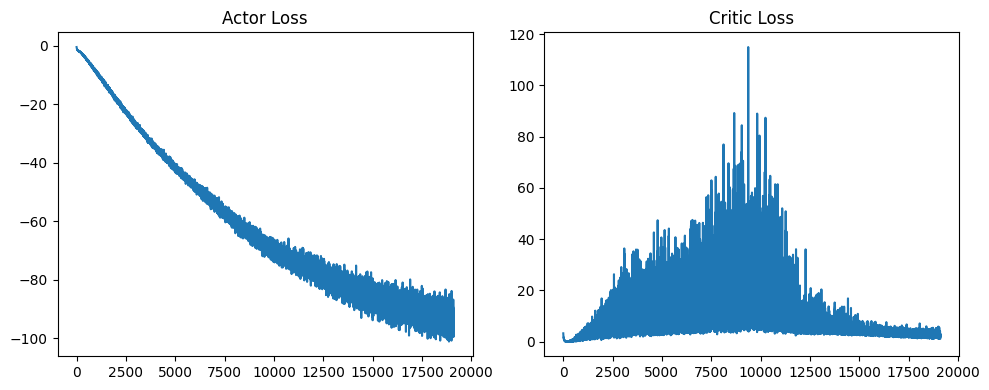

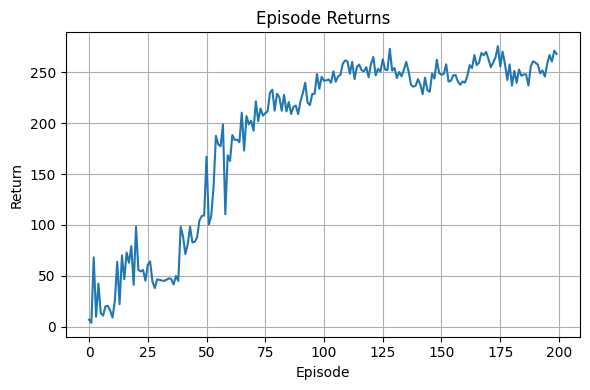

Training with sparsity 0.95


Training episodes:   0%|          | 0/200 [00:00<?, ?it/s]

Episode 0, Return: 10.15


Training episodes:   6%|▌         | 12/200 [00:01<00:25,  7.48it/s]

Episode 10, Return: 10.04


...

Training episodes:  90%|█████████ | 181/200 [02:46<00:25,  1.32s/it]

Episode 180, Return: 289.50


Training episodes:  96%|█████████▌| 191/200 [02:58<00:11,  1.23s/it]

Episode 190, Return: 290.31


Training episodes: 100%|██████████| 200/200 [03:10<00:00,  1.05it/s]


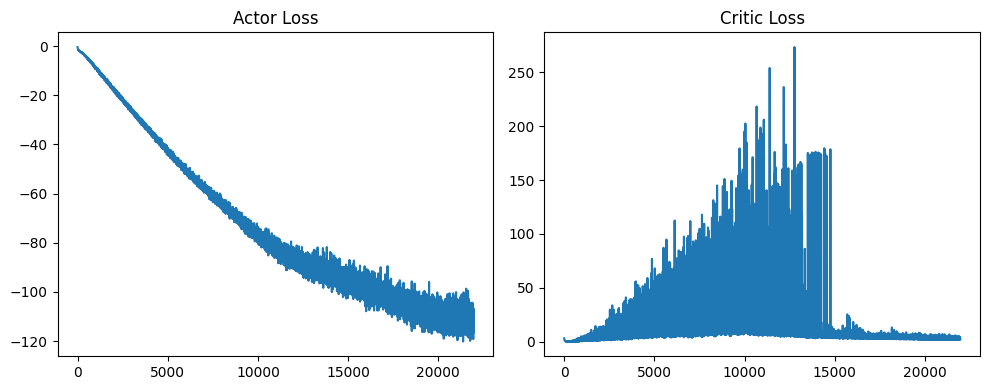

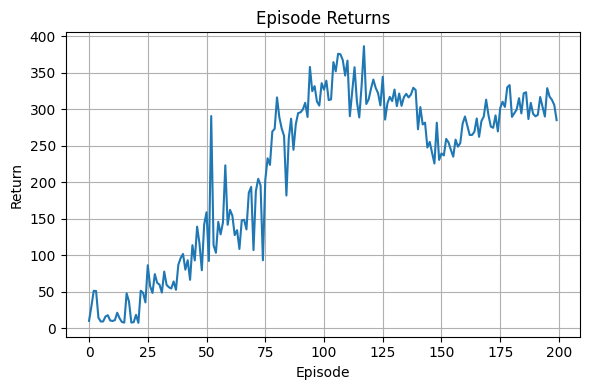

Training with sparsity 0.98


Training episodes:   2%|▎         | 5/200 [00:00<00:04, 40.99it/s]

Episode 0, Return: 8.85


Training episodes:   5%|▌         | 10/200 [00:01<00:24,  7.84it/s]

Episode 10, Return: 39.27


...

Training episodes:  91%|█████████ | 182/200 [01:43<00:01, 13.31it/s]

Episode 180, Return: 3.74


Training episodes:  96%|█████████▌| 192/200 [01:44<00:00, 13.44it/s]

Episode 190, Return: 3.49


Training episodes: 100%|██████████| 200/200 [01:45<00:00,  1.90it/s]


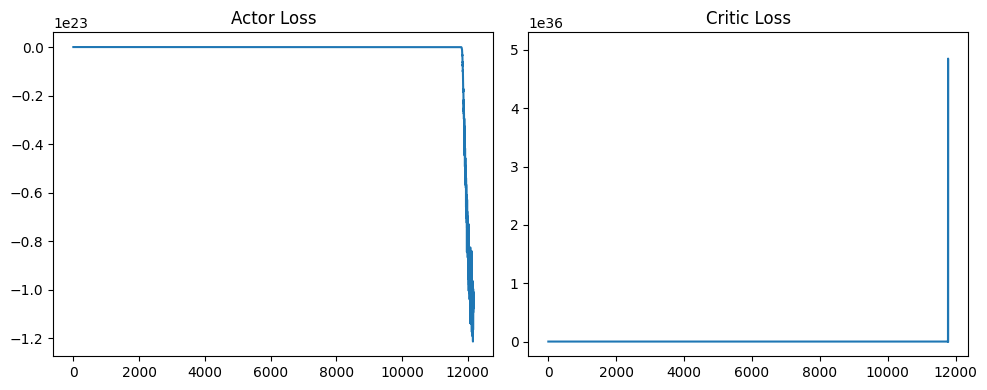

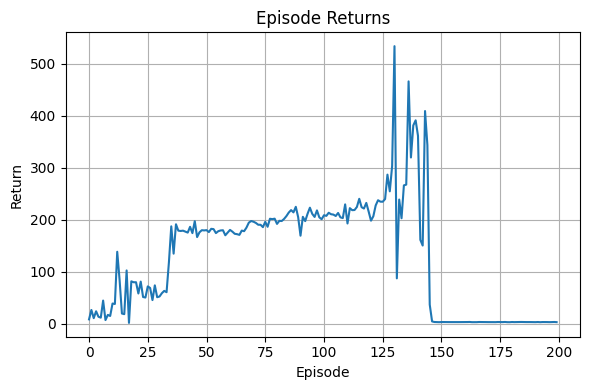

In [5]:
for sparsity in [0.90, 0.95, 0.98]:
    print(f"Training with sparsity {sparsity}")
    returns, actor_loss, critic_loss = train_dapd("Hopper-v4", num_episodes=200, sparsity=sparsity)
    plot_loss(actor_loss, critic_loss)
    plot_returns(returns)

c:\Users\Proprio\AppData\Local\Programs\Python\Python311\Lib\site-packages\gymnasium\envs\registration.py:517: DeprecationWarning: WARN: The environment Ant-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


Training with sparsity 0.9


Training episodes:   0%|          | 0/200 [00:00<?, ?it/s]

Episode 0, Return: -15.05


Training episodes:   6%|▌         | 11/200 [00:26<06:52,  2.18s/it]

...

Training episodes:  90%|█████████ | 181/200 [19:23<02:50,  8.96s/it]

Episode 180, Return: 159.52


Training episodes:  96%|█████████▌| 191/200 [20:31<01:03,  7.05s/it]

Episode 190, Return: 1234.82


Training episodes: 100%|██████████| 200/200 [21:16<00:00,  6.38s/it]


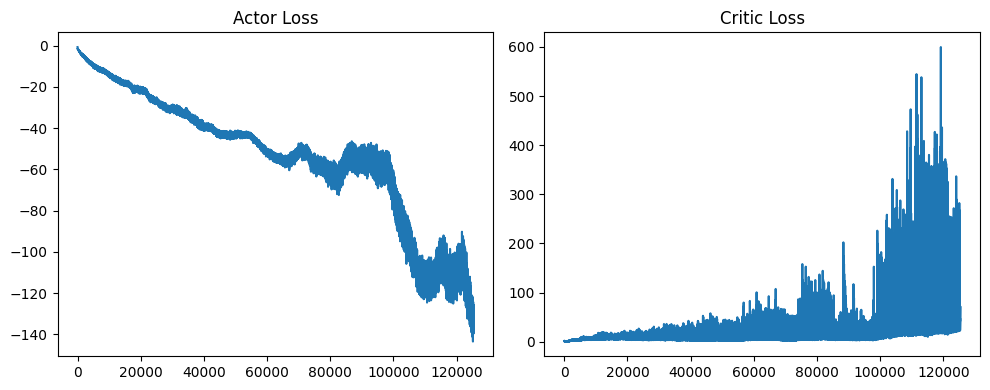

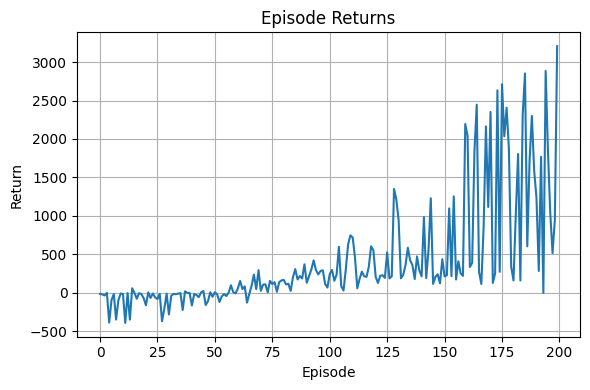

Training with sparsity 0.95


Training episodes:   0%|          | 0/200 [00:00<?, ?it/s]

Episode 0, Return: -50.43


Training episodes:   6%|▌         | 11/200 [00:27<03:34,  1.14s/it]

Episode 10, Return: 3.05


...

Training episodes:  90%|█████████ | 181/200 [14:49<01:36,  5.08s/it]

Episode 180, Return: 365.43


Training episodes:  96%|█████████▌| 191/200 [15:46<00:57,  6.41s/it]

Episode 190, Return: 1462.51


Training episodes: 100%|██████████| 200/200 [16:53<00:00,  5.07s/it]


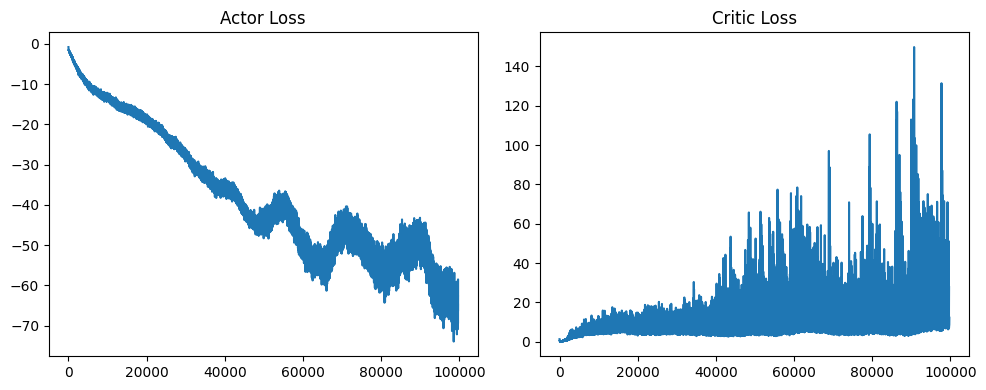

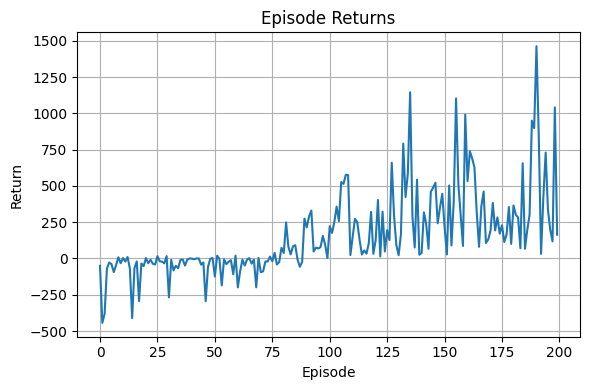

Training with sparsity 0.98


Training episodes:   0%|          | 0/200 [00:00<?, ?it/s]

Episode 0, Return: -9.17


Training episodes:   6%|▌         | 11/200 [00:23<03:11,  1.01s/it]

Episode 10, Return: -13.24


...

Training episodes:  90%|█████████ | 181/200 [20:31<01:51,  5.87s/it]

Episode 180, Return: 66.18


Training episodes:  96%|█████████▌| 191/200 [22:02<01:20,  8.96s/it]

Episode 190, Return: 734.89


Training episodes: 100%|██████████| 200/200 [23:10<00:00,  6.95s/it]


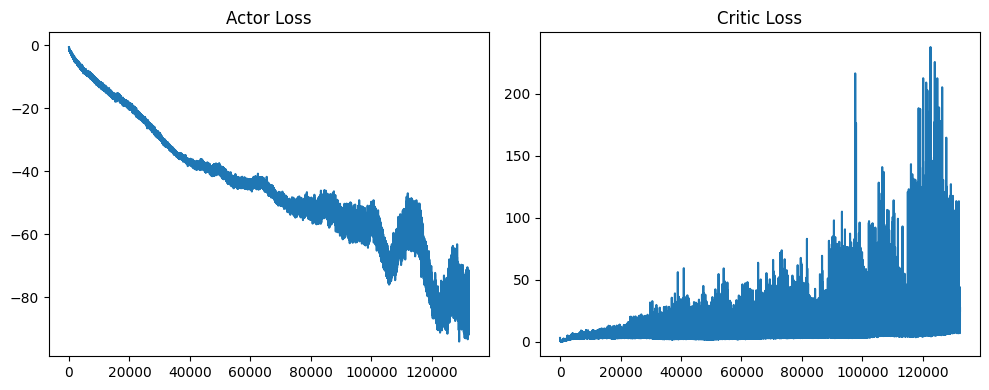

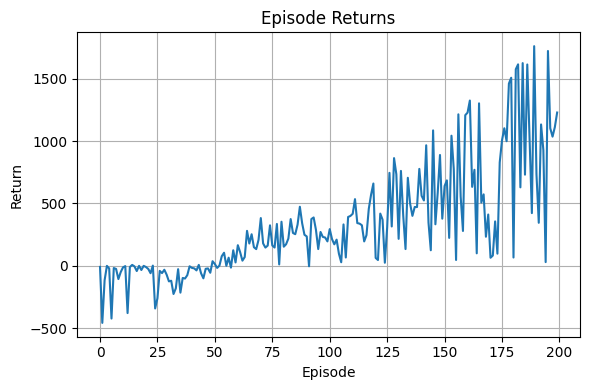

In [6]:
for sparsity in [0.90, 0.95, 0.98]:
    print(f"Training with sparsity {sparsity}")
    returns, actor_loss, critic_loss = train_dapd("Ant-v4", num_episodes=200, sparsity=sparsity)
    plot_loss(actor_loss, critic_loss)
    plot_returns(returns)